<a href="https://colab.research.google.com/github/CarsonBaraka04/-AI-Coursework-2025/blob/main/Diamonds_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
from google.colab import files
uploaded = files.upload()   # click "Choose Files" and select diamonds.csv (or the zip)


Saving diamonds.csv.zip to diamonds.csv.zip


In [8]:
!unzip diamonds.csv.zip
# then read the CSV that appears

Archive:  diamonds.csv.zip
replace diamonds.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [9]:
import pandas as pd
print(list(uploaded.keys()))        # shows uploaded filenames
df = pd.read_csv('diamonds.csv')    # or the actual uploaded name
df.head()
df.info()


['diamonds.csv.zip']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [13]:
# Check for duplicates and remove them
df.drop_duplicates(inplace=True)

# Confirm there are no missing values
df.isnull().sum()


,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [16]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.head()


,Unnamed: 0,carat,depth,table,price,x,y,z
0,1,0.23,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,63.3,58.0,335,4.34,4.35,2.75


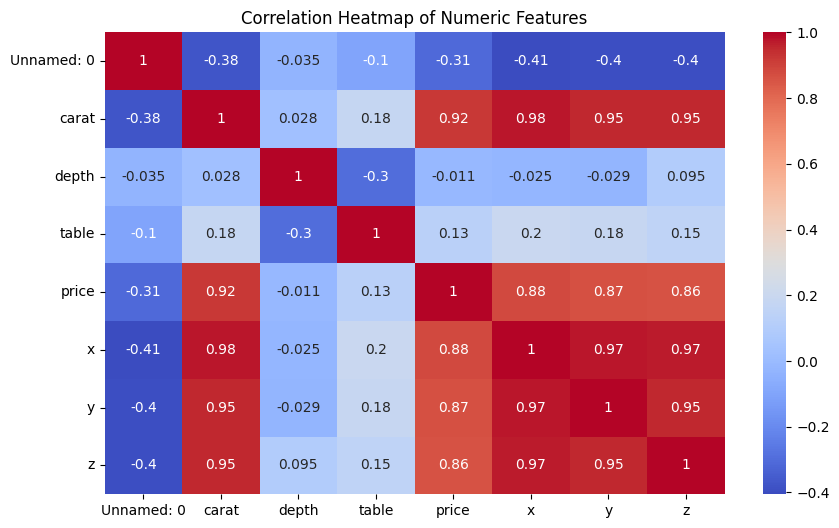

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [19]:
diamonds_model = df.sample(12500, random_state=42).reset_index(drop=True)
diamonds_model.shape



(12500, 11)

In [20]:
diamonds_model.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1389,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,50053,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,41646,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,42378,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,17245,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


In [21]:
X = diamonds_model.drop('price', axis=1)
y = diamonds_model['price']


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_features = ['carat','depth','table','x','y','z']

# Scale numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(diamonds_model[numeric_features])


In [23]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a new DataFrame for PCA results
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df['price'] = diamonds_model['price']
pca_df.head()


,PC1,PC2,price
0,-2.966127,0.332066,559
1,-0.696406,-0.839772,2201
2,-1.835197,0.737420,1238
3,-1.523158,-0.503515,1304
4,2.899012,1.284566,6901


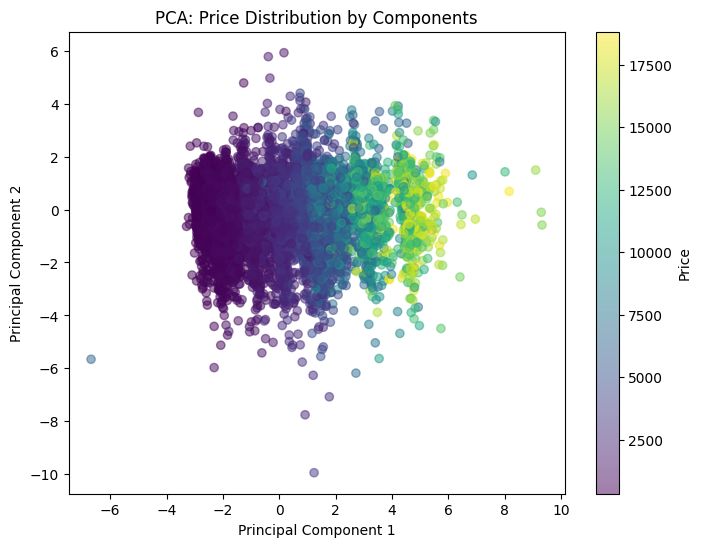

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['price'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Price')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Price Distribution by Components')
plt.show()


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_pca = pca_df[['PC1','PC2']]
y_pca = pca_df['price']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pca, y_pca, test_size=0.2, random_state=42)

pca_lr = LinearRegression()
pca_lr.fit(X_train_p, y_train_p)

y_pred_p = pca_lr.predict(X_test_p)

print("PCA R²:", r2_score(y_test_p, y_pred_p))
print("PCA RMSE:", np.sqrt(mean_squared_error(y_test_p, y_pred_p)))


PCA R²: 0.8055772996058582
PCA RMSE: 1756.027477562555


In [28]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = ['carat','depth','table','x','y','z']
categorical_features = ['cut','color','clarity']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])


In [30]:
from sklearn.model_selection import train_test_split

# Separate features and target again
X = diamonds_model.drop('price', axis=1)
y = diamonds_model['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [31]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

models = [
    ('Lasso', Lasso(alpha=0.1, random_state=42)),
    ('Ridge', Ridge(alpha=1, random_state=42))
]

for name, model in models:
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"{name} R²: {r2_score(y_test, y_pred):.4f}")
    print(f"{name} RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}\n")


Lasso R²: 0.9232
Lasso RMSE: 1103.68

Ridge R²: 0.9230
Ridge RMSE: 1104.94



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.183e+09, tolerance: 1.577e+07
  model = cd_fast.enet_coordinate_descent(


| Model             | R²   | RMSE | Comment                                               |
| ----------------- | ---- | ---- | ----------------------------------------------------- |
| Linear Regression | 0.92 | 1103.70 | Strong baseline model, predicts prices accurately with small errors. |
| PCA Regression    | 0.8055 | 1756.02 | Accuracy drops after dimensionality reduction         |
| Lasso Regression  | 0.9232 | 1103.68  | Slightly less accurate, helps feature selection       |
| Ridge Regression  | 0.9230 | 1104.94  | Best overall performance, handles overfitting         |
